Project #5: Video Stitching and Processing 

## CS445: Computational Photography - Spring 2020

### Setup


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [2]:
# modify to where you store your project data including utils
datadir = "" 

utilfn = datadir + "utils.py"
!cp "$utilfn" .
imagesfn = datadir + "images"
!cp -r "$imagesfn" .

cp: ./utils.py and utils.py are identical (not copied).
cp: ./images and images are identical (not copied).


In [3]:
!pip uninstall opencv-python -y
# downgrade OpenCV a bit to use SIFT
!pip install opencv-contrib-python==3.4.2.17 --force-reinstall
!pip install ffmpeg-python # for converting to video

import ffmpeg
import cv2
import numpy as np
import os
from numpy.linalg import svd, inv
import utils
%matplotlib inline
from matplotlib import pyplot as plt

ERROR: Could not find a version that satisfies the requirement opencv-contrib-python==3.4.2.17 (from versions: 3.4.11.45, 3.4.13.47, 3.4.14.51, 3.4.15.55, 3.4.16.59, 3.4.17.61, 3.4.17.63, 3.4.18.65, 4.4.0.46, 4.5.1.48, 4.5.2.52, 4.5.3.56, 4.5.4.58, 4.5.4.60, 4.5.5.62, 4.5.5.64, 4.6.0.66, 4.7.0.68, 4.7.0.72, 4.8.0.74, 4.8.0.76, 4.8.1.78, 4.9.0.80, 4.10.0.82, 4.10.0.84, 4.11.0.86, 4.12.0.88, 4.13.0.90, 4.13.0.92)
ERROR: No matching distribution found for opencv-contrib-python==3.4.2.17
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [ffmpeg-python]0m [ffmpeg-python]


### Part I: Stitch two key frames 

#### This involves:
1. compute homography H between two frames; 
2. project each frame onto the same surface;
3. blend the surfaces.

Check that your homography is correct by plotting four points that form a square in frame 270 and their projections in each image.

In [4]:
def score_projection(pt1, pt2):
    '''
    Score corresponding to the number of inliers for RANSAC
    Input: pt1 and pt2 are 2xN arrays of N points such that pt1[:, i] and pt2[:,i] should be close in Euclidean distance if they are inliers
    Outputs: score (scalar count of inliers) and inliers (1xN logical array)
    '''
    threshold = 5.0  # pixel distance threshold for classifying inliers
    diff = pt1 - pt2
    distances = np.sqrt(np.sum(diff**2, axis=0))
    inliers = distances < threshold
    score = int(np.sum(inliers))
    return score, inliers


def auto_homography(Ia, Ib, homography_func=None, normalization_func=None):
    '''
    Computes a homography that maps points from Ia to Ib

    Input: Ia and Ib are images
    Output: H is the homography

    '''
    if Ia.dtype == 'float32' and Ib.dtype == 'float32':
        Ia = (Ia*255).astype(np.uint8)
        Ib = (Ib*255).astype(np.uint8)

    Ia_gray = cv2.cvtColor(Ia, cv2.COLOR_BGR2GRAY)
    Ib_gray = cv2.cvtColor(Ib, cv2.COLOR_BGR2GRAY)

    # Initiate SIFT detector
    sift = cv2.xfeatures2d.SIFT_create()

    # find the keypoints and descriptors with SIFT
    kp_a, des_a = sift.detectAndCompute(Ia_gray, None)
    kp_b, des_b = sift.detectAndCompute(Ib_gray, None)

    # BFMatcher with default params
    bf = cv2.BFMatcher()
    matches = bf.knnMatch(des_a, des_b, k=2)

    # Apply ratio test
    good = []
    for m, n in matches:
        if m.distance < 0.75*n.distance:
            good.append(m)

    numMatches = int(len(good))
    matches = good

    # Xa and Xb are 3xN matrices that contain homogeneous coordinates for the N
    # matching points for each image
    Xa = np.ones((3, numMatches))
    Xb = np.ones((3, numMatches))

    for idx, match_i in enumerate(matches):
        Xa[:, idx][0:2] = kp_a[match_i.queryIdx].pt
        Xb[:, idx][0:2] = kp_b[match_i.trainIdx].pt

    ## RANSAC
    niter = 1000
    best_score = 0
    n_to_sample = 4  # minimum number of point correspondences needed to solve for a homography

    H = None
    in_idx = None

    for t in range(niter):
        # estimate homography
        subset = np.random.choice(numMatches, n_to_sample, replace=False)
        pts1 = Xa[:, subset]
        pts2 = Xb[:, subset]

        H_t = homography_func(pts1, pts2, normalization_func)

        # score homography
        Xb_ = np.dot(H_t, Xa)  # project points from first image to second using H

        score_t, inliers_t = score_projection(Xb[:2, :]/Xb[2, :], Xb_[:2, :]/Xb_[2, :])

        if score_t > best_score:
            best_score = score_t
            H = H_t
            in_idx = inliers_t

    print('best score: {:02f}'.format(best_score))

    # Re-estimate H using all inliers for a more accurate result
    if in_idx is not None and np.sum(in_idx) >= n_to_sample:
        H = homography_func(Xa[:, in_idx], Xb[:, in_idx], normalization_func)
        print('Re-estimated H using {:d} inliers'.format(int(np.sum(in_idx))))

    return H

In [8]:
def computeHomography(pts1, pts2, normalization_func=None):
    '''
    Compute homography that maps from pts1 to pts2 using SVD. Normalization is optional.

    Input: pts1 and pts2 are 3xN matrices for N points in homogeneous coordinates.
    Output: H is a 3x3 matrix, such that pts2~=H*pts1
    '''
    N = pts1.shape[1]

    # Convert to inhomogeneous coordinates
    x1 = pts1[0, :] / pts1[2, :]
    y1 = pts1[1, :] / pts1[2, :]
    x2 = pts2[0, :] / pts2[2, :]
    y2 = pts2[1, :] / pts2[2, :]

    # Build the 2N x 9 matrix A such that Ah = 0
    A = np.zeros((2 * N, 9))
    for i in range(N):
        A[2*i]     = [-x1[i], -y1[i], -1,      0,      0,  0, x2[i]*x1[i], x2[i]*y1[i], x2[i]]
        A[2*i + 1] = [     0,      0,  0, -x1[i], -y1[i], -1, y2[i]*x1[i], y2[i]*y1[i], y2[i]]

    # Solve Ah = 0 via SVD; solution is the last row of Vh (right singular vector for smallest singular value)
    U, S, Vh = np.linalg.svd(A)
    h = Vh[-1, :]
    H = h.reshape(3, 3)

    return H


best score: 221.000000
Re-estimated H using 221 inliers
H (normalized):
[[ 1.00000000e+00  4.17919845e-02 -2.04154869e+02]
 [ 1.14205543e-02  9.45588751e-01 -1.44319874e+01]
 [ 3.63056146e-04  2.85885437e-05  8.21427777e-01]]


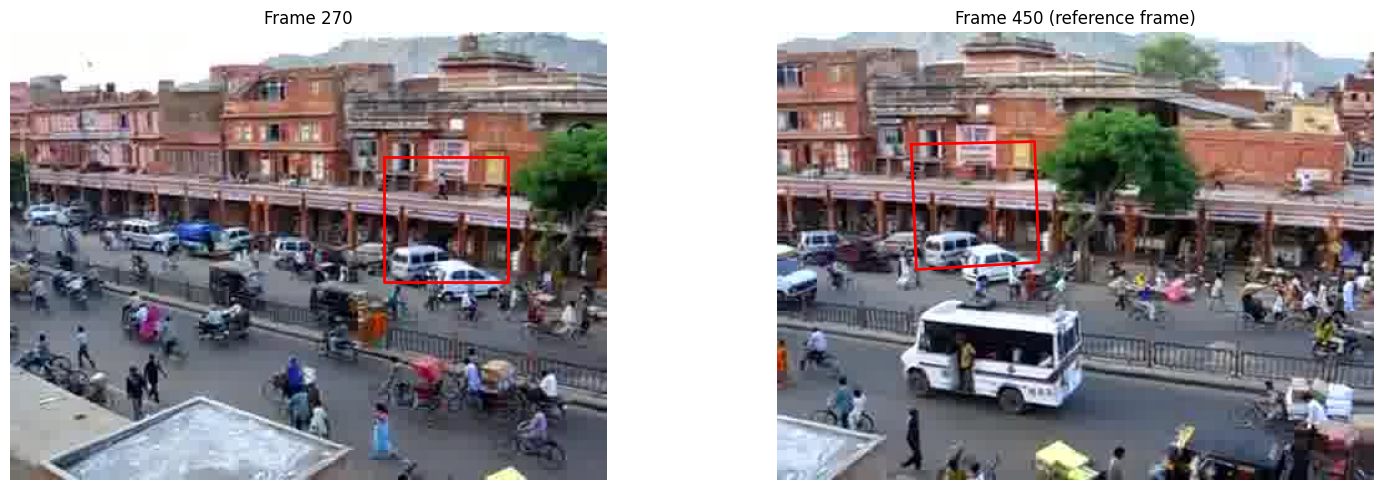

Saved: part1_box_projection.png


In [10]:
# images location
im1_path = './images/input/frames/f0270.jpg'
im2_path = './images/input/frames/f0450.jpg'

# Load images (OpenCV loads as BGR)
im1 = cv2.imread(im1_path)
im2 = cv2.imread(im2_path)

H = auto_homography(im1, im2, computeHomography)
print("H (normalized):")
print(H / H.max())

# Define a square in frame 270 using homogeneous coordinates
box_pts = np.array([[300, 400, 400, 300, 300],
                    [100, 100, 200, 200, 100],
                    [  1,   1,   1,   1,   1]], dtype=float)

# Plot the box in frame 270 (im1)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].imshow(im1[:, :, [2, 1, 0]])
axes[0].plot(box_pts[0, :], box_pts[1, :], 'r-', linewidth=2)
axes[0].set_title('Frame 270')
axes[0].axis('off')

# Project box_pts from frame 270 into the reference frame 450 using homography H
box_pts_proj = H @ box_pts
box_pts_proj = box_pts_proj / box_pts_proj[2, :]  # convert back from homogeneous

# Plot the projected box in frame 450 (im2)
axes[1].imshow(im2[:, :, [2, 1, 0]])
axes[1].plot(box_pts_proj[0, :], box_pts_proj[1, :], 'r-', linewidth=2)
axes[1].set_title('Frame 450 (reference frame)')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('part1_box_projection.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: part1_box_projection.png")



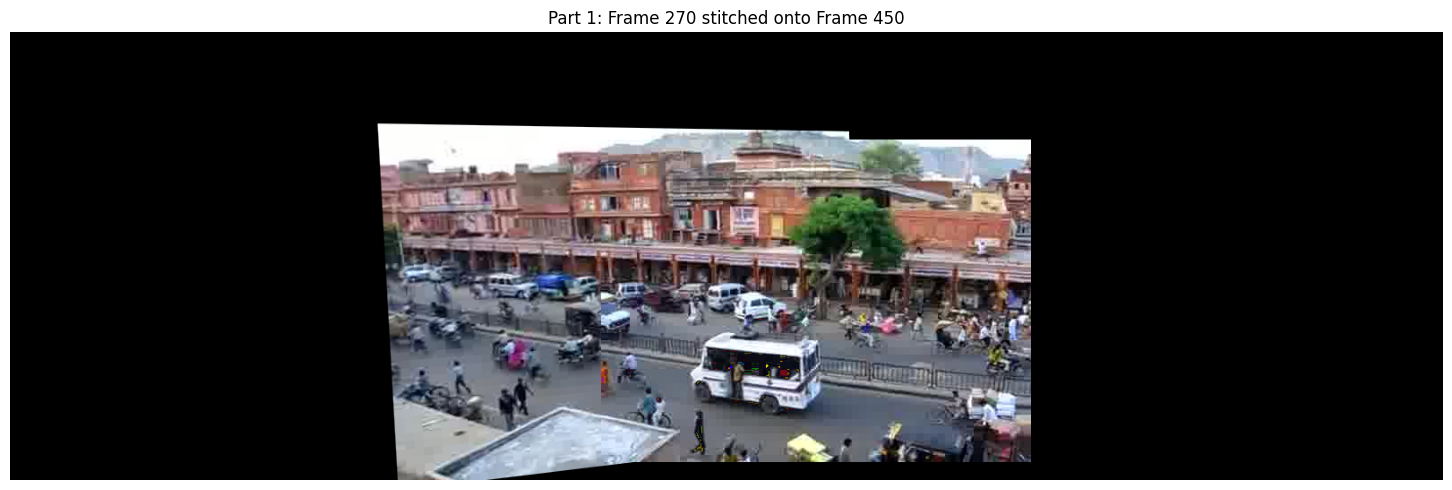

Saved: part1_stitched.png


In [7]:
projectedWidth = 1600
projectedHeight = 500

# Translation matrix that shifts the reference frame (450) to roughly the center of the panorama
Tr = np.array([[1, 0, 660],
               [0, 1, 120],
               [0, 0,   1]], dtype=float)

# Project frame 450 (reference) to the panorama using only the translation
projIm2 = cv2.warpPerspective(im2, Tr, (projectedWidth, projectedHeight))

# Project frame 270 (source) to the panorama: first H maps im1->im2, then Tr shifts to panorama
H_adjusted = Tr @ H
projIm1 = cv2.warpPerspective(im1, H_adjusted, (projectedWidth, projectedHeight))

# Blend: fill zero pixels in the reference projection with pixels from the source projection
blended = utils.blendImages(projIm1, projIm2)

# Display result (convert BGR -> RGB for matplotlib)
plt.figure(figsize=(16, 5))
plt.imshow(blended[:, :, [2, 1, 0]])
plt.title('Part 1: Frame 270 stitched onto Frame 450')
plt.axis('off')
plt.tight_layout()
plt.savefig('part1_stitched.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: part1_stitched.png")




### Part II: Panorama using five key frames

Produce a panorama by mapping five key frames [90, 270, 450, 630, 810] onto the same reference frame 450.  


In [ ]:
key_frames_idx = np.array([90, 270, 450, 630, 810])-1

frames = np.zeros((len(key_frames_idx), im1.shape[0], im1.shape[1], im1.shape[2]),dtype='uint8')
for n in range(len(key_frames)):
  frames[n] = cv2.imread("./images/input/frames/f0{num}.jpg".format(num=str(key_frames_idx[n]+1).zfill(3)))

# TO DO solution




### Part 3: Map the video to the reference plane

Project each frame onto the reference frame (using same size panorama) to create a video that shows the portion of the panorama revealed by each frame

In [ ]:
# read all the images
import os 
dir_frames = 'images/input/frames'
filenames = []
filesinfo = os.scandir(dir_frames)

filenames = [f.path for f in filesinfo if f.name.endswith(".jpg")]
filenames.sort(key=lambda f: int(''.join(filter(str.isdigit, f))))

frameCount = len(filenames)
frameHeight, frameWidth, frameChannels = cv2.imread(filenames[0]).shape
frames = np.zeros((frameCount, frameHeight, frameWidth, frameChannels),dtype='uint8')

for idx, file_i in enumerate(filenames):
  frames[idx] = cv2.imread(file_i)



In [ ]:
# TO DO part 3 solution

# create your video (see tips)

### Part 4: Create background panorama

Create a background panorama based on the result from Part 3.


In [ ]:
# TO DO part 4

### Part 5: Create background movie

Generate a movie that looks like the input movie but shows only background pixels. For each frame of the movie, you need to estimate a projection from the panorama to that frame. Your solution can use the background image you created in Part 4 and the per-frame homographies you created in Part 3. 


In [ ]:
# TO DO part 5



### Part 6: Create foreground movie

In the background video, moving objects are removed. In each frame, those pixels that are different enough than the background color are considered foreground. For each frame determine foreground pixels and generate a movie that emphasizes or includes only foreground pixels.

In [ ]:
# TO DO part 6


## Bells and whistles